# 01 — Truncamiento del prior (tSNPE)

En este tutorial cargamos el MAF entrenado en el tutorial 00 y exploramos cómo funciona el truncamiento secuencial del prior (tSNPE).

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn

from zbi.utils import (
    compute_bounding_box, TruncatedBoxPrior, 
    load_checkpoint, load_maf_from_checkpoint, plot_ppc
)

%matplotlib inline

El checkpoint guardó las clases como `__main__.SimuladorLineal` y `__main__.EmbeddingNet`. Necesitamos definirlas aquí para poder cargar el modelo.

In [29]:
class SimuladorLineal(zbi.Simulator):
    def __init__(self):
        super().__init__()
        self.x_grid = torch.linspace(-5, 5, 100)

    def simulate(self, theta: torch.Tensor, seed: int | None = None) -> torch.Tensor:
        if seed is not None:
            torch.manual_seed(seed)
        a, b = theta[0].item(), theta[1].item()
        y = a * self.x_grid + b + 0.1 * torch.randn(100)
        return y

simulador = SimuladorLineal()

class EmbeddingNet(nn.Module):
    def __init__(self, dim_in: int = 100, dim_out: int = 5):
        super().__init__()
        self.net = nn.Linear(dim_in, dim_out)

    def forward(self, x):
        return self.net(x)

Cargar el checkpoint y reconstruir el MAF

In [30]:
ckpt = load_checkpoint("runs/tutorial_00/models/round_00000_500.pt")

emb_config = ckpt.get("embedding_net_config", {})
emb_kwargs = {k: v for k, v in emb_config.items() if k != "class"}
embedding_net = EmbeddingNet(**emb_kwargs)

maf = load_maf_from_checkpoint(ckpt, embedding_net=embedding_net)

x_o = torch.load("runs/tutorial_00/x_o.pt", weights_only=True)
print(f"MAF cargado. x_o shape: {x_o.shape}")

MAF cargado. x_o shape: torch.Size([1, 100])


Usamos el MAF para generar 10 000 muestras de $p(\theta \mid x_o)$.

In [31]:
maf.eval()
with torch.no_grad():
    samples = maf.sample(10_000, x_o).numpy()

print(f"Muestras: {samples.shape}")
print(f"Media: theta_0={samples[:,0].mean():.4f}, theta_1={samples[:,1].mean():.4f}")
print(f"Std:   theta_0={samples[:,0].std():.4f}, theta_1={samples[:,1].std():.4f}")

Muestras: (10000, 2)
Media: theta_0=1.0303, theta_1=0.5088
Std:   theta_0=0.0615, theta_1=0.0167


Algoritmo de truncamiento:

1. Toma $N$ muestras de la posterior $\{\theta^{(i)}\}_{i=1}^N$
2. Calcula el log-prob de cada una bajo la posterior: $\log p(\theta^{(i)} \mid x_o)$
3. Encuentra el máximo: $L_{\max} = \max_i \log p(\theta^{(i)} \mid x_o)$
4. Selecciona las muestras con log-prob cercano al máximo:

   $$\text{mask} = \log p(\theta^{(i)} \mid x_o) > L_{\max} + \log(\text{threshold})$$

5. La nueva caja es `[min(mask), max(mask)]` por dimensión, recortada al prior original.


In [32]:
from torch.distributions import Uniform

prior_original = Uniform(torch.tensor([-3.0, -3.0]), torch.tensor([3.0, 3.0]))
original_bounds = torch.stack([prior_original.low, prior_original.high])

maf.eval()
with torch.no_grad():
    theta_t = torch.from_numpy(samples).float()
    log_probs = maf.forward(theta_t, x_o.expand(theta_t.shape[0], -1)).numpy()

thresholds = [1e-3, 0.01, 0.1, 0.5]
boxes = {}

for th in thresholds:
    bounds = compute_bounding_box(
        theta_t, torch.from_numpy(log_probs), th, original_bounds
    )
    boxes[th] = bounds
    vol = (bounds[1] - bounds[0]).prod().item()
    pct = vol / (6 * 6) * 100


Cada rectángulo muestra la región que se usaría como proposal en la siguiente ronda.

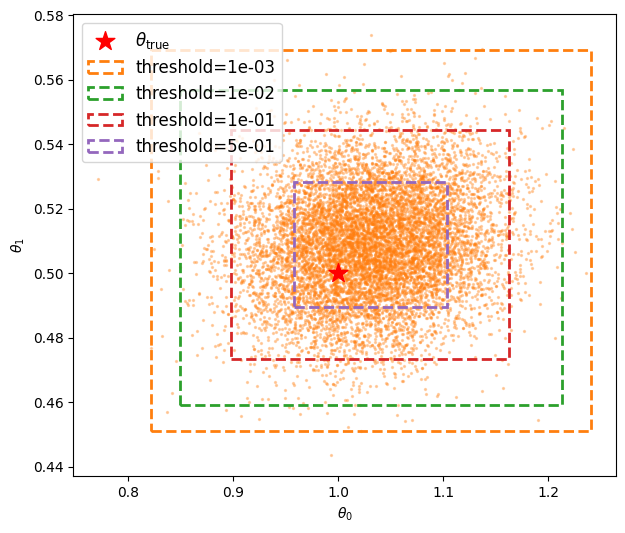

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.3, color="C1")
ax.scatter(1.0, 0.5, marker="*", s=200, color="red", zorder=5, label="$\\theta_{\\mathrm{true}}$")

colors = ["C1", "C2", "C3", "C4"]
for i, (th, bounds) in enumerate(boxes.items()):
    low, high = bounds[0], bounds[1]
    w, h = high[0] - low[0], high[1] - low[1]
    rect = plt.Rectangle(low.numpy(), w, h, fill=False,
                         edgecolor=colors[i], lw=2, ls="--",
                         label=f"threshold={th:.0e}")
    ax.add_patch(rect)

ax.set_xlabel("$\\theta_0$")
ax.set_ylabel("$\\theta_1$")
ax.legend(fontsize=12)

El truncamiento se maneja separadamente del entrenamiento mediante `update_proposal`.
Esta función carga un checkpoint entrenado, samplea la posterior, computa los bounds
con un threshold elegido por el usuario, y los guarda en `proposal.json`.

In [34]:
import zbi

zbi.update_proposal("runs/tutorial_00", checkpoint="round_00000_500.pt", threshold=1e-6)

In [35]:
import json

with open("runs/tutorial_00/proposal.json") as f:
    print(json.dumps(json.load(f), indent=2))

{
  "prior_meta": {
    "type": "Uniform",
    "low": [
      -3.0,
      -3.0
    ],
    "high": [
      3.0,
      3.0
    ]
  },
  "bounds": {
    "low": [
      0.7995522618293762,
      0.44403207302093506
    ],
    "high": [
      1.2530418634414673,
      0.5809760093688965
    ]
  },
  "threshold": 1e-06,
  "checkpoint": "round_00000_500.pt"
}


`simulate` lee `proposal.json` automáticamente para rondas > 0 y construye
el `TruncatedBoxPrior` con los bounds guardados.

In [36]:
zbi.simulate("runs/tutorial_00", round=1, n_sims=500, seed=2)
zbi.train("runs/tutorial_00", round=1, n_sims=500)
zbi.update_proposal("runs/tutorial_00", checkpoint="round_00001_500.pt", threshold=1e-6)
print("Ronda 1 completada")

Simulating: 100%|██████████| 500/500 [00:00<00:00, 4903.36it/s]

Ronda 1: 500 sims nuevas, 500 acumuladas (offset=500)
Usando simulaciones: offset=500, n_sims=500


Epoch   0  train_loss=-0.3848  val_loss=-0.6645
Epoch   1  train_loss=-0.8890  val_loss=-1.1537
Epoch   2  train_loss=-1.3619  val_loss=-1.5937
Epoch   3  train_loss=-1.7897  val_loss=-1.9842
Epoch   4  train_loss=-2.1573  val_loss=-2.3014
Epoch   5  train_loss=-2.4451  val_loss=-2.5430
Epoch   6  train_loss=-2.6835  val_loss=-2.7903
Epoch   7  train_loss=-2.9386  val_loss=-3.0541
Epoch   8  train_loss=-3.2220  val_loss=-3.3409
Epoch   9  train_loss=-3.5261  val_loss=-3.6547
Epoch  10  train_loss=-3.8522  val_loss=-3.9975
Epoch  11  train_loss=-4.1765  val_loss=-4.3269
Epoch  12  train_loss=-4.4914  val_loss=-4.6634
Epoch  13  train_loss=-4.7732  val_loss=-4.9031
Epoch  14  train_loss=-4.9958  val_loss=-5.1447
Epoch  15  train_loss=-5.1758  val_loss=-5.3074
Epoch  16  train_loss=-5.3485  val_loss=-5.4192
Epoch  17  train_loss=-5.4922  val_loss=-5.5492
Epoch  18  train_loss=-5.6289  val_loss=-5.6631
Epoch  19  train_loss=-5.7472  val_loss=-5.7577
Epoch  20  train_loss=-5.8757  val_loss=

In [37]:
with open("runs/tutorial_00/proposal.json") as f:
    print(json.dumps(json.load(f), indent=2))

{
  "prior_meta": {
    "type": "Uniform",
    "low": [
      -3.0,
      -3.0
    ],
    "high": [
      3.0,
      3.0
    ]
  },
  "bounds": {
    "low": [
      0.9807695746421814,
      0.4821329414844513
    ],
    "high": [
      1.0175073146820068,
      0.5509127974510193
    ]
  },
  "threshold": 1e-06,
  "checkpoint": "round_00001_500.pt"
}
